In [5]:
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
df_data = pd.read_csv('datasets/opentender_clean_2022_2024.csv')

In [7]:
df_data.head()

,ocid,buyer_name,vendor_name,HPS,contract_value,procurement_method,category,item_description,date
0,ocds-20h3g7-12482010,Pemerintah Daerah Kota Surabaya,PT. DUTA BHUANA JAYA,7.445028e+08,6.666604e+08,consultancyServices,services,Jasa Konsultansi Badan Usaha Konstruksi,2024-02-02
1,ocds-20h3g7-12487010,Pemerintah Daerah Kota Surabaya,"MARGA PERKASA,CV",4.793422e+09,4.129909e+09,NaN,works,Pekerjaan Konstruksi,2024-01-15
2,ocds-20h3g7-12492010,Pemerintah Daerah Kota Surabaya,CV. Naga Kencana Wiratama,2.255991e+09,2.012700e+09,NaN,works,Pekerjaan Konstruksi,2024-01-15
3,ocds-20h3g7-12496010,Pemerintah Daerah Kota Surabaya,CV. Tiga Points Jaya Karya,3.425503e+09,2.566207e+09,NaN,works,Pekerjaan Konstruksi,2024-01-16
4,ocds-20h3g7-12504010,Pemerintah Daerah Kota Surabaya,CV. Citra Karya,1.307263e+09,1.231890e+09,NaN,works,Pekerjaan Konstruksi,2024-01-15


In [8]:
df_data.head()
df_data.info()
df_data.describe()

<class 'pandas.DataFrame'>
RangeIndex: 292852 entries, 0 to 292851
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   ocid                292852 non-null  str    
 1   buyer_name          288191 non-null  str    
 2   vendor_name         164113 non-null  str    
 3   HPS                 163738 non-null  float64
 4   contract_value      164113 non-null  float64
 5   procurement_method  26328 non-null   str    
 6   category            164113 non-null  str    
 7   item_description    164113 non-null  str    
 8   date                292852 non-null  str    
dtypes: float64(2), str(7)
memory usage: 48.0 MB


,HPS,contract_value
count,1.637380e+05,1.641130e+05
mean,3.817390e+09,3.529409e+09
std,3.461689e+10,3.307242e+10
min,1.760000e+04,1.050000e+04
25%,3.795271e+08,3.504016e+08
50%,6.947567e+08,6.399824e+08
75%,1.800000e+09,1.660123e+09
max,4.286669e+12,4.242926e+12


*CLEANING NOISE*

In [9]:
df_data = df_data.drop(columns=["procurement_method"])
#kudrop noise tinggi

In [10]:
df_data = df_data.dropna(subset=[
    "vendor_name",
    "contract_value"
])

In [11]:
df_data = df_data.dropna(subset=["HPS"])

In [12]:
df_data = df_data.dropna(subset=["buyer_name"])

In [13]:
df_data = df_data[df_data["HPS"] > 0]
df_data = df_data[df_data["contract_value"] > 0]

FEATURE ENGINEERING

rasio kontrak

In [14]:
#Rasio kontrak terhadap HPS
df_data["ratio"] = df_data["contract_value"] / df_data["HPS"]

In [15]:
#B. DISCOUNT PERCENTAGE
df_data["discount_percentage"] = (
    (df_data["HPS"] - df_data["contract_value"])
    / df_data["HPS"]
) * 100

In [16]:
# C. VENDOR WIN COUNT
# Berapa kali vendor menang tender

vendor_win_count = (
    df_data.groupby("vendor_name")
    .size()
    .reset_index(name="vendor_win_count")
)
# merge ke dataframe utama
df_data = df_data.merge(
    vendor_win_count,
    on="vendor_name",
    how="left"
)


In [17]:
# D. VENDOR-INSTANSI FREQUENCY
# Seberapa sering vendor menang di instansi tertentu

vendor_instansi_frequency = (
    df_data.groupby(["vendor_name", "buyer_name"])
    .size()
    .reset_index(name="vendor_instansi_frequency")
)

# merge kembali
df_data = df_data.merge(
    vendor_instansi_frequency,
    on=["vendor_name", "buyer_name"],
    how="left"
)

In [18]:
# E. AVERAGE VENDOR RATIO
# Rata-rata ratio tiap vendor

avg_vendor_ratio = (
    df_data.groupby("vendor_name")["ratio"]
    .mean()
    .reset_index(name="avg_vendor_ratio")
)

# merge kembali
df_data = df_data.merge(
    avg_vendor_ratio,
    on="vendor_name",
    how="left"
)

In [19]:
# OPTIONAL: ROUND AGAR RAPI

df_data["ratio"] = df_data["ratio"].round(4)

df_data["discount_percentage"] = (
    df_data["discount_percentage"].round(2)
)

df_data["avg_vendor_ratio"] = (
    df_data["avg_vendor_ratio"].round(4)
)

In [20]:
# CEK HASIL FEATURE ENGINEERING

print("Feature engineering selesai.\n")

print(df_data[
    [
        "vendor_name",
        "buyer_name",
        "HPS",
        "contract_value",
        "ratio",
        "discount_percentage",
        "vendor_win_count",
        "vendor_instansi_frequency",
        "avg_vendor_ratio"
    ]
].head())

# SAVE FEATURED DATASET

df_data.to_csv(
    "featured_procurement_dataset.csv",
    index=False
)

print("\nDataset berhasil disimpan.")

Feature engineering selesai.

                  vendor_name                       buyer_name           HPS  \
0        PT. DUTA BHUANA JAYA  Pemerintah Daerah Kota Surabaya  7.445028e+08   
1            MARGA PERKASA,CV  Pemerintah Daerah Kota Surabaya  4.793422e+09   
2   CV. Naga Kencana Wiratama  Pemerintah Daerah Kota Surabaya  2.255991e+09   
3  CV. Tiga Points Jaya Karya  Pemerintah Daerah Kota Surabaya  3.425503e+09   
4             CV. Citra Karya  Pemerintah Daerah Kota Surabaya  1.307263e+09   

   contract_value   ratio  discount_percentage  vendor_win_count  \
0    6.666604e+08  0.8954                10.46                97   
1    4.129909e+09  0.8616                13.84                 2   
2    2.012700e+09  0.8922                10.78                 3   
3    2.566207e+09  0.7491                25.09                 1   
4    1.231890e+09  0.9423                 5.77                 1   

   vendor_instansi_frequency  avg_vendor_ratio  
0                          6   

In [21]:
print(df_data.info())

<class 'pandas.DataFrame'>
RangeIndex: 161422 entries, 0 to 161421
Data columns (total 13 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ocid                       161422 non-null  str    
 1   buyer_name                 161422 non-null  str    
 2   vendor_name                161422 non-null  str    
 3   HPS                        161422 non-null  float64
 4   contract_value             161422 non-null  float64
 5   category                   161422 non-null  str    
 6   item_description           161422 non-null  str    
 7   date                       161422 non-null  str    
 8   ratio                      161422 non-null  float64
 9   discount_percentage        161422 non-null  float64
 10  vendor_win_count           161422 non-null  int64  
 11  vendor_instansi_frequency  161422 non-null  int64  
 12  avg_vendor_ratio           161422 non-null  float64
dtypes: float64(5), int64(2), str(6)
memory u

**ISOLATION FOREST**

In [22]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

In [23]:
features = [
    "HPS",
    "contract_value",
    "ratio",
    "discount_percentage",
    "vendor_win_count",
    "vendor_instansi_frequency",
    "avg_vendor_ratio"
]

X = df_data[features]

In [24]:
X = X.dropna()

In [25]:
df_model = df_data.loc[X.index].copy()

In [26]:
df_model = df_data.loc[X.index].copy()

parameter

In [27]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [28]:
iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.02,
    random_state=42
)

FIT MODEL

In [29]:
iso_forest.fit(X_scaled)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.02
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [30]:
df_model["anomaly_label"] = iso_forest.predict(X_scaled)

In [31]:
df_model["anomaly_score"] = (
    iso_forest.decision_function(X_scaled)
)

In [32]:
top_anomalies = df_model.sort_values(
    by="anomaly_score"
).head(20)

In [33]:
print(top_anomalies[
    [
        "vendor_name",
        "buyer_name",
        "HPS",
        "contract_value",
        "ratio",
        "discount_percentage",
        "vendor_win_count",
        "anomaly_score"
    ]
])

                                     vendor_name  \
56104              PT BRANTAS ABIPRAYA (Persero)   
74555              PT BRANTAS ABIPRAYA (Persero)   
74429              PT BRANTAS ABIPRAYA (Persero)   
19847              PT BRANTAS ABIPRAYA (Persero)   
37721              PT BRANTAS ABIPRAYA (Persero)   
95543              PT BRANTAS ABIPRAYA (Persero)   
99362                          SAPTA KARYA ABADI   
74557            PT. WASKITA KARYA (PERSERO) Tbk   
95512            PT. WASKITA KARYA (PERSERO) Tbk   
38178   PT. Pembangunan Perumahan (Persero)  Tbk   
19684            PT. WASKITA KARYA (PERSERO) Tbk   
37893   PT. Pembangunan Perumahan (Persero)  Tbk   
38105              PT BRANTAS ABIPRAYA (Persero)   
117038  PT. Pembangunan Perumahan (Persero)  Tbk   
74790   PT. Pembangunan Perumahan (Persero)  Tbk   
138575  PT. Pembangunan Perumahan (Persero)  Tbk   
74831   PT. Pembangunan Perumahan (Persero)  Tbk   
74430                 PT. NINDYA KARYA (Persero)   
19821   PT. 

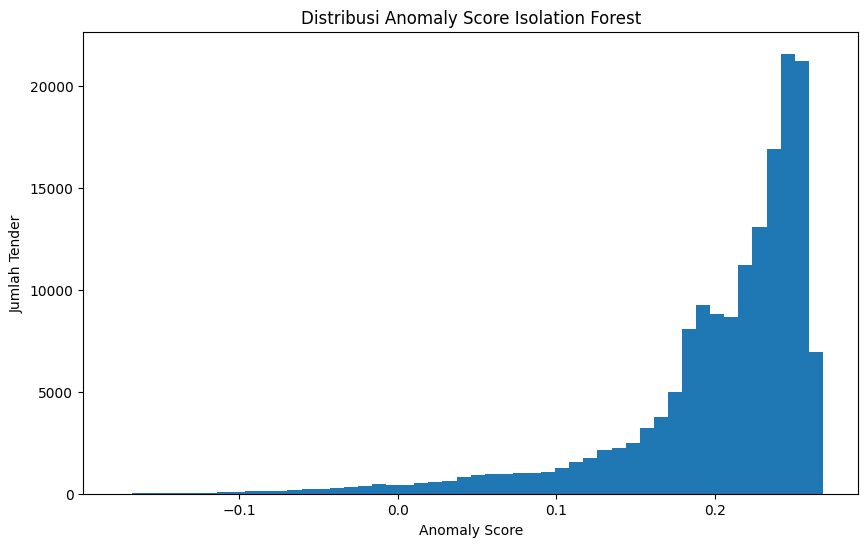

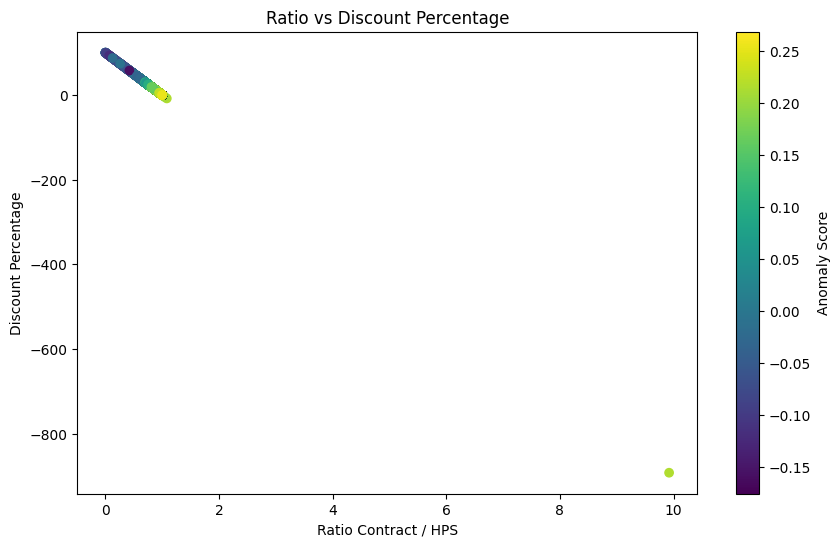

TOP SUSPICIOUS VENDORS
vendor_name
Firma KJSB Subkhi Abdul Hakim At Tigholy dan Rekan   -0.158629
PT. ENSEVAL PUTERA MEGATRADING. Tbk                  -0.151866
PT.BIOGEN SCIENTIFIC                                 -0.149281
PT. ENSEVAL PUTERA MEGATRADING, Tbk                  -0.147734
PT BRANTAS ABIPRAYA (Persero)                        -0.141380
PT. Pembangunan Perumahan (Persero)  Tbk             -0.139737
PT. WASKITA KARYA (PERSERO) Tbk                      -0.131909
PT ADHI KARYA (Persero) Tbk                          -0.123318
Admiral Blesensa Abadi                               -0.121421
PT. MITRA FAJAR SELARAS                              -0.119931
Name: anomaly_score, dtype: float64


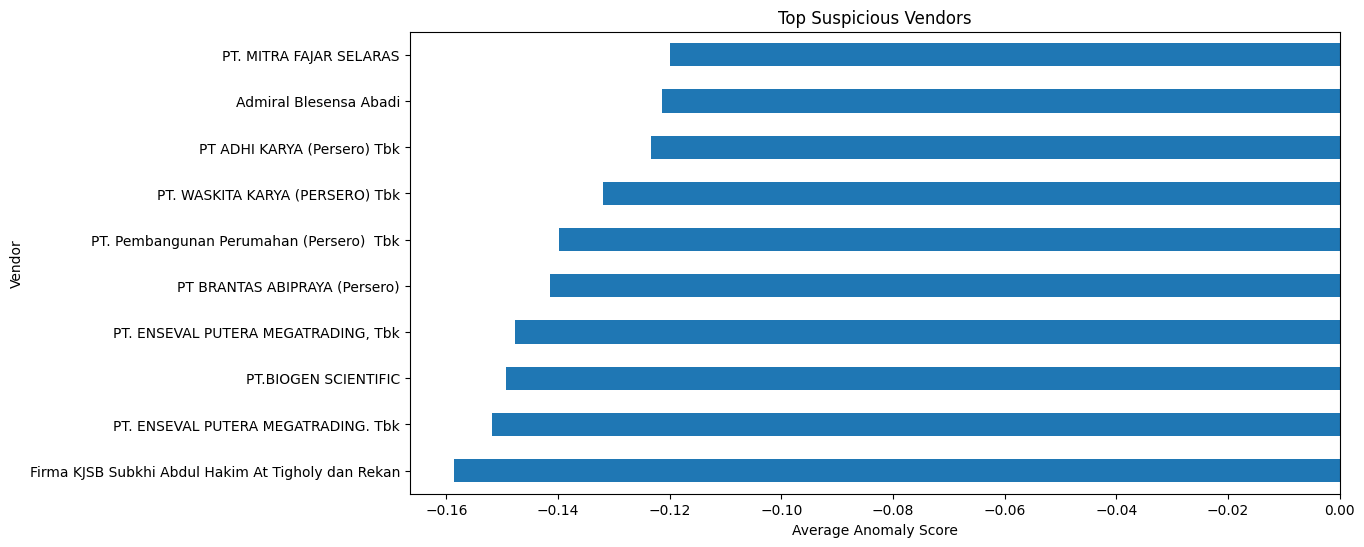

INSTANSI PALING RAWAN

buyer_name
PDAM Delta Tirta Sidoarjo                                   0.049226
PD BKK Kesugihan Kabupaten Cilacap                          0.049560
Badan Pusat Statistik                                       0.062621
Lembaga Perlindungan Saksi dan Korban Republik Indonesia    0.067784
Kementerian Pekerjaan Umum dan Perumahan Rakyat             0.084821
Pemerintah Daerah Kota Denpasar                             0.091077
Pemerintah Daerah Kabupaten Jayawijaya                      0.092993
PDAM Kabupaten Semarang                                     0.095726
PDAM Tirtamarta Yogyakarta                                  0.098016
Kejaksaan Republik Indonesia                                0.103440
Name: anomaly_score, dtype: float64


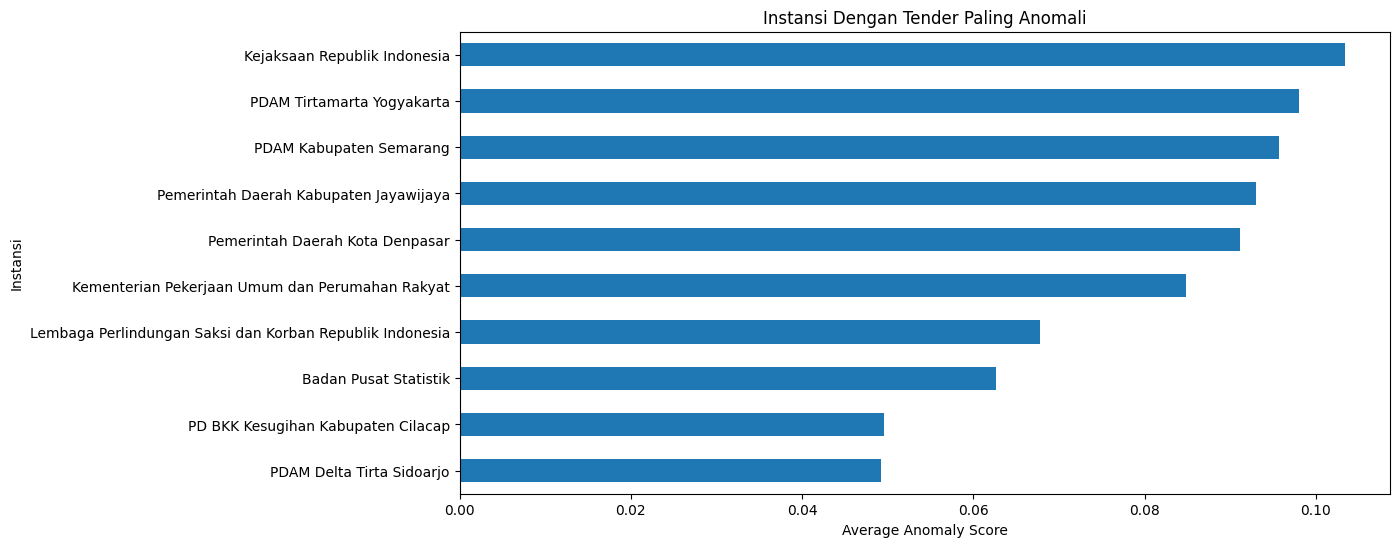

VENDOR DOMINANCE

vendor_name
PT. ALOCITA MANDIRI                        153
PT. Gumilang Sajati                        143
PT. ARTEK UTAMA                            120
PT. GANESHA PRATAMA CONSULTANT             116
CV. TIKA KREATIF DESAIN KONSULTAN          109
PT. DUTA BHUANA JAYA                        97
PT. WANDRA CIPTA ENGINEERING CONSULTANT     94
PT. INKONEKSI IZI KONSULTAN                 92
PT. Inasa Sakha Kirana                      91
PT. DARMASRAYA MITRA AMERTA                 90
Name: count, dtype: int64


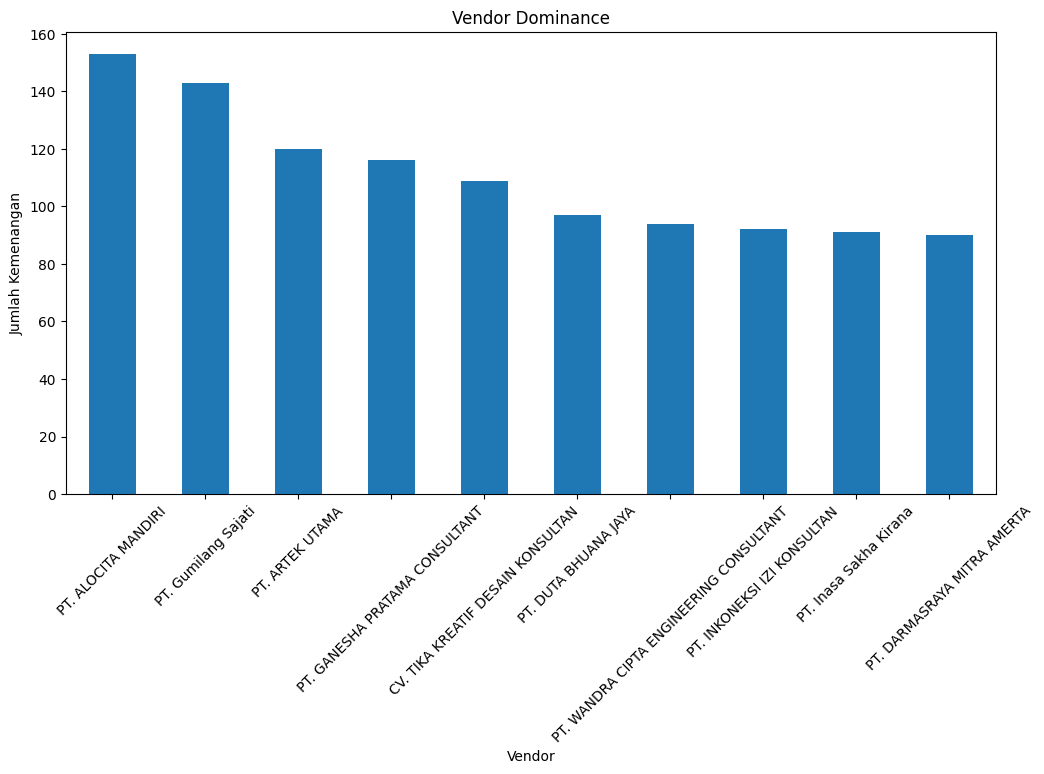

TOP 20 MOST SUSPICIOUS TENDERS

                                     vendor_name  \
56104              PT BRANTAS ABIPRAYA (Persero)   
74555              PT BRANTAS ABIPRAYA (Persero)   
74429              PT BRANTAS ABIPRAYA (Persero)   
19847              PT BRANTAS ABIPRAYA (Persero)   
37721              PT BRANTAS ABIPRAYA (Persero)   
95543              PT BRANTAS ABIPRAYA (Persero)   
99362                          SAPTA KARYA ABADI   
74557            PT. WASKITA KARYA (PERSERO) Tbk   
95512            PT. WASKITA KARYA (PERSERO) Tbk   
38178   PT. Pembangunan Perumahan (Persero)  Tbk   
19684            PT. WASKITA KARYA (PERSERO) Tbk   
37893   PT. Pembangunan Perumahan (Persero)  Tbk   
38105              PT BRANTAS ABIPRAYA (Persero)   
117038  PT. Pembangunan Perumahan (Persero)  Tbk   
74790   PT. Pembangunan Perumahan (Persero)  Tbk   
138575  PT. Pembangunan Perumahan (Persero)  Tbk   
74831   PT. Pembangunan Perumahan (Persero)  Tbk   
74430                 PT. NINDYA

In [34]:
# VISUALIZATION & DASHBOARD
# Isolation Forest Fraud Detection

import pandas as pd
import matplotlib.pyplot as plt

# 1. HISTOGRAM ANOMALY SCORE

plt.figure(figsize=(10,6))

plt.hist(
    df_model["anomaly_score"],
    bins=50
)

plt.xlabel("Anomaly Score")
plt.ylabel("Jumlah Tender")
plt.title("Distribusi Anomaly Score Isolation Forest")

plt.show()

# 2. SCATTER PLOT
# Ratio vs Discount Percentage

plt.figure(figsize=(10,6))

scatter = plt.scatter(
    df_model["ratio"],
    df_model["discount_percentage"],
    c=df_model["anomaly_score"]
)

plt.xlabel("Ratio Contract / HPS")
plt.ylabel("Discount Percentage")
plt.title("Ratio vs Discount Percentage")

plt.colorbar(scatter, label="Anomaly Score")

plt.show()

# 3. TOP SUSPICIOUS VENDORS

top_suspicious_vendors = (
    df_model.groupby("vendor_name")["anomaly_score"]
    .mean()
    .sort_values()
    .head(10)
)

print("TOP SUSPICIOUS VENDORS")
print(top_suspicious_vendors)

# VISUALISASI TOP SUSPICIOUS VENDORS

plt.figure(figsize=(12,6))

top_suspicious_vendors.plot(kind="barh")

plt.xlabel("Average Anomaly Score")
plt.ylabel("Vendor")
plt.title("Top Suspicious Vendors")

plt.show()

# 4. INSTANSI RAWAN

risky_agencies = (
    df_model.groupby("buyer_name")["anomaly_score"]
    .mean()
    .sort_values()
    .head(10)
)

print("INSTANSI PALING RAWAN\n")

print(risky_agencies)

# VISUALISASI INSTANSI RAWAN

plt.figure(figsize=(12,6))

risky_agencies.plot(kind="barh")

plt.xlabel("Average Anomaly Score")
plt.ylabel("Instansi")
plt.title("Instansi Dengan Tender Paling Anomali")

plt.show()

# 5. VENDOR DOMINANCE

vendor_dominance = (
    df_model["vendor_name"]
    .value_counts()
    .head(10)
)
print("VENDOR DOMINANCE\n")

print(vendor_dominance)

# VISUALISASI VENDOR DOMINANCE

plt.figure(figsize=(12,6))

vendor_dominance.plot(kind="bar")

plt.xlabel("Vendor")
plt.ylabel("Jumlah Kemenangan")
plt.title("Vendor Dominance")

plt.xticks(rotation=45)

plt.show()

# 6. TOP ANOMALY TABLE
top_anomalies = df_model.sort_values(
    by="anomaly_score"
).head(20)

print("TOP 20 MOST SUSPICIOUS TENDERS\n")

print(
    top_anomalies[
        [
            "vendor_name",
            "buyer_name",
            "HPS",
            "contract_value",
            "ratio",
            "discount_percentage",
            "vendor_win_count",
            "anomaly_score"
        ]
    ]
)
# OPTIONAL SAVE
top_anomalies.to_csv(
    "top_suspicious_tenders.csv",
    index=False
)

print("\nDashboard & visualisasi selesai.")

# Model LOCAL OUTLIER FACTOR 

In [35]:
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler

In [36]:
#Pilih features yang relevan untuk LOF
features = [
    "HPS",
    "contract_value",
    "ratio",
    "discount_percentage",
    "vendor_win_count",
    "vendor_instansi_frequency",
    "avg_vendor_ratio"
]
X = df_data[features]

In [37]:
#Handling misssing values
X = X.dropna()
df_lof = df_data.loc[X.index].copy()

In [38]:
#scaling

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [39]:
#Train local outlier factor
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.02
)

In [40]:
#fut and save a prediction
lof_labels = lof.fit_predict(X_scaled)

df_lof["lof_label"] = lof_labels

In [41]:
#Anomaly score (negative_outlier_factor_)
#semakin negatif, semakin anomali
df_lof["lof_score"] = lof.negative_outlier_factor_

In [42]:
print("LOF anomaly detection selesai.\n")
print(df_lof["lof_label"].value_counts())

LOF anomaly detection selesai.

lof_label
 1    158193
-1      3229
Name: count, dtype: int64


In [43]:
# =========================================================
# 9. TOP ANOMALIES
# =========================================================

top_lof_anomalies = (
    df_lof
    .sort_values(by="lof_score")
    .head(20)
)

print("\n===================================")
print("TOP LOF ANOMALIES")
print("===================================\n")

print(
    top_lof_anomalies[
        [
            "vendor_name",
            "buyer_name",
            "HPS",
            "contract_value",
            "ratio",
            "discount_percentage",
            "vendor_win_count",
            "vendor_instansi_frequency",
            "avg_vendor_ratio",
            "lof_score"
        ]
    ]
)


TOP LOF ANOMALIES

                                           vendor_name  \
95820                                  Gilang Gemilang   
1628                                PT. CITRA SHIPYARD   
55863                               PT. CITRA SHIPYARD   
61006                       PT.HASTI ANUGRAH NUSANTARA   
82097   KOPERASI KONSUMEN PUSAT KOPERASI KARTIKA TIDAR   
154813                            PT. ARKAN PUTRA TAMA   
112007                            PT. TRIMURTI PERKASA   
1584                     PT. Trinika Teknologi Mandiri   
77434                       CV. BENUM GEMILANG MANDIRI   
101031  KOPERASI KONSUMEN PUSAT KOPERASI KARTIKA TIDAR   
49073                            CV Bintang Bima Sakti   
32086                                      ubay dillah   
108262                              CV. CAHAYA BERLIAN   
119634                           CV. DANADYAKSA IHATRA   
86101                                      Geotrimukti   
62662                            PT SARANA NIKITA JA

In [44]:
# =========================================================
# 10. SAVE HASIL
# =========================================================

top_lof_anomalies.to_csv(
    "top_lof_anomalies.csv",
    index=False
)

print("\nLOF modeling selesai.")


LOF modeling selesai.


In [48]:
if_anomalies = df_model[
    df_model["anomaly_label"] == -1
]
lof_anomalies = df_lof[
    df_lof["lof_label"] == -1
]

In [49]:
common_vendors = set(
    if_anomalies["vendor_name"]
).intersection(
    set(lof_anomalies["vendor_name"])
)

print("Jumlah vendor overlap:", len(common_vendors))

print(common_vendors)

Jumlah vendor overlap: 223
{'PT. PERENTJANA DJAJA', 'PT Pelayaran Tempuran Emas Tbk.', 'PT AGUNG JAYA SEJAHTERA', 'PT. SETAJI SUTADHO SEJAHTERA', 'PT. Sinar Tunas Karya Utama', 'PT. GRAMEDIA', 'PT. WIJAYA KARYA (Persero) Tbk.', 'CV. NADI GUNA KARYA', 'PT. Ciriajasa Cipta Mandiri', 'CV. BERKAT ANUGRAH', 'PT. WIJAYA KARYA BANGUNAN GEDUNG', 'CV ARTHA MAS KAYANA', 'PT. Jaya Karya Pasundan', 'PT. SCALARINDO UTAMA CONSULT', 'PT Total Indo Bangunusa', 'CV. KARYA AMALIA', 'PT. Infosys Solusi Terpadu', 'PT. ABATA HASTA PERSADA', 'CV.CITRA AJYAD', 'PT. BINTANG INTI REKATAMA', 'PT. MITRA SOLUSI INFOKOM', 'PT. WASKITA KARYA (PERSERO) Tbk', 'PT. Paragon Prima Karya', 'CV Pratama Abadi Sejahtera', 'AIR MAS PERKASA', 'PT. HIDUP INDAH BERKAH', 'SEKAR ANUGRAH MANDIRI', 'GURILA SAKTI', 'PT. ABADI HARUMAN JAYA', 'octorama anugrah perdana', 'PT. INDONESIA DEFENCE SERVICES', 'PT. PUTRA KENCANA', 'PT.TUNAS TEHNIK SEJATI', 'PT. JOGLO MULTI AYU', 'PT. Nusa Kreasi Persada', 'PT. SILFARONA PERDANA', 'PT. MARI B

In [50]:
print(
    if_anomalies[
        ["ratio", "discount_percentage"]
    ].describe()
)

print(
    lof_anomalies[
        ["ratio", "discount_percentage"]
    ].describe()
)

             ratio  discount_percentage
count  3229.000000          3229.000000
mean      0.803070            19.692967
std       0.198784            19.878396
min       0.000700             0.000000
25%       0.744200             4.440000
50%       0.844100            15.590000
75%       0.955600            25.580000
max       1.000000            99.930000
             ratio  discount_percentage
count  3229.000000          3229.000000
mean      0.888851            11.114899
std       0.191167            19.116684
min       0.000700          -892.160000
25%       0.800000             1.500000
50%       0.902200             9.780000
75%       0.985000            20.000000
max       9.921600            99.930000
